# HopeEXP — Task C: Extracción de Fragmentos
**Modelo base:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Token classification con etiquetas BIO (`O`, `B-SPAN`, `I-SPAN`)  
**Objetivo:** extraer hasta 3 spans exactos que describan el resultado esperado o evitado

## 0. Setup e Imports

In [1]:
%pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split as sk_split

sys.path.insert(0, os.path.abspath('.'))

from src.span_model import build_span_model, build_span_tokenizer, load_span_model
from src.span_utils import (
    aggregate_predictions,
    build_dataloader,
    build_source_text,
    collect_logits,
    compute_class_weights,
    format_metrics,
    limit_records,
    load_primary_labels,
    load_records,
    predictions_to_submission,
    save_json,
    set_seed,
    summarize_dataset,
)
from src.span_experiments import (
    DEFAULT_CANDIDATE_MODELS,
    aggregate_predictions_tuned,
    compare_span_models,
    evaluate_span_model,
    train_span_model,
    tune_postprocess,
)

print('Imports correctos')

Imports correctos


In [3]:
SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'Dispositivo: CUDA ({torch.cuda.get_device_name(0)})')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Dispositivo: Apple Silicon (MPS)')
else:
    DEVICE = torch.device('cpu')
    print('Dispositivo: CPU')

Dispositivo: CUDA (NVIDIA H200 NVL)


## 1. Configuración de Hiperparámetros

In [4]:
TRAIN_PATH = './HopeEXP_Train.jsonl'
TEST_PATH = './HopeEXP_Test_unlabeled.jsonl'
DEV_SIZE = 0.20

TEXT_COL = 'source_text'
ID_COL = 'row_id'
LANG_COL = 'lang'
PRIMARY_COL = 'primary_label'

MODEL_NAME = 'microsoft/mdeberta-v3-base'
NUM_LABELS = 3
MAX_LENGTH = 512
STRIDE = 64

BATCH_SIZE = 16
COMPARISON_EPOCHS = 3
NUM_EPOCHS = 25
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE = 3
GRAD_CLIP = 1.0

USE_CLASS_WEIGHTS = True
PRIMARY_LABELS_PATH = None

MAX_TRAIN_EXAMPLES = None
MAX_DEV_EXAMPLES = None
MAX_TEST_EXAMPLES = None

OUTPUT_DIR = './outputs/task_c_spans_notebook'
COMPARISON_DIR = os.path.join(OUTPUT_DIR, 'model_comparison')
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, 'best_model')
BEST_MODEL_NAME = 'best_model_task_c'
SUBMISSION_NAME = 'submission_task_c_notebook.json'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(COMPARISON_DIR, exist_ok=True)
print('Configuracion lista')
print(f'MODEL_NAME={MODEL_NAME}')
print(f'BATCH_SIZE={BATCH_SIZE} | COMPARISON_EPOCHS={COMPARISON_EPOCHS} | NUM_EPOCHS={NUM_EPOCHS}')

Configuracion lista
MODEL_NAME=microsoft/mdeberta-v3-base
BATCH_SIZE=16 | COMPARISON_EPOCHS=3 | NUM_EPOCHS=25


## 2. Carga y Preparación de Datos

In [5]:
full_train_records = load_records(TRAIN_PATH)
test_records = load_records(TEST_PATH)

train_records, dev_records = sk_split(
    full_train_records,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=[record.get('primary_label', '') for record in full_train_records],
)

train_records = limit_records(train_records, MAX_TRAIN_EXAMPLES)
dev_records = limit_records(dev_records, MAX_DEV_EXAMPLES)
test_records = limit_records(test_records, MAX_TEST_EXAMPLES)

def records_to_df(records):
    rows = []
    for record in records:
        spans = record.get('span_annotations', []) or []
        rows.append({
            'row_id': record.get('row_id'),
            'lang': record.get('lang'),
            'primary_label': record.get('primary_label'),
            'title': record.get('title'),
            'selftext': record.get('selftext'),
            'source_text': build_source_text(record),
            'span_count': len(spans),
            'span_texts': ' ||| '.join(span.get('span', '') for span in spans),
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df['char_length'] = df['source_text'].str.len()
        df['is_hopeful'] = df['primary_label'].isin(['General Hope', 'Realistic Hope', 'Unrealistic Hope', 'Sarcastic Hope'])
    return df

train_df = records_to_df(train_records)
dev_df = records_to_df(dev_records)
test_df = records_to_df(test_records)

print(f'Train completo: {len(full_train_records)} muestras')
print(f'  -> Train: {len(train_records)} | Dev: {len(dev_records)} (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})')
print(f'  -> Test (sin etiquetas): {len(test_records)} muestras')
print()
print('Resumen train:', summarize_dataset(train_records))
print('Resumen dev:', summarize_dataset(dev_records))
display(train_df.head(3))

Train completo: 4857 muestras
  -> Train: 3885 | Dev: 972 (split 80/20)
  -> Test (sin etiquetas): 2082 muestras

Resumen train: {'total_records': 3885, 'hopeful_records': 2430, 'records_with_spans': 2429}
Resumen dev: {'total_records': 972, 'hopeful_records': 608, 'records_with_spans': 608}


,row_id,lang,primary_label,title,selftext,source_text,span_count,span_texts,char_length,is_hopeful
0,5377,EN,Sarcastic Hope,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",My Partner Finally Remembered My Birthday—How ...,1,I have so much hope that things will magically...,803,True
1,7161,EN,Not Hope,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Reddittors make finding answers ridiculously t...,0,,339,False
2,4124,ES,Realistic Hope,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Alguien está o ha estado en una banda?\nMe gus...,1,Me gustaría estar en una banda musical,125,True


## 3. Análisis de Desbalanceo y EDA

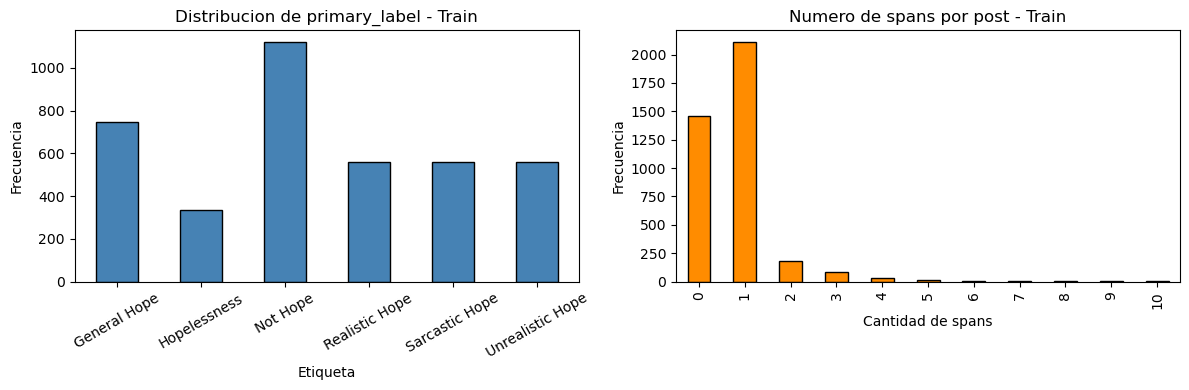

,train,dev
primary_label,,
Not Hope,1120,280
General Hope,749,188
Realistic Hope,561,140
Sarcastic Hope,560,140
Unrealistic Hope,560,140
Hopelessness,335,84


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df['primary_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribucion de primary_label - Train')
axes[0].set_xlabel('Etiqueta')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=30)

train_df['span_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
)
axes[1].set_title('Numero de spans por post - Train')
axes[1].set_xlabel('Cantidad de spans')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_label_distribution.png'), dpi=150)
plt.show()

display(pd.concat([
    train_df['primary_label'].value_counts().rename('train'),
    dev_df['primary_label'].value_counts().rename('dev')
], axis=1).fillna(0).astype(int))

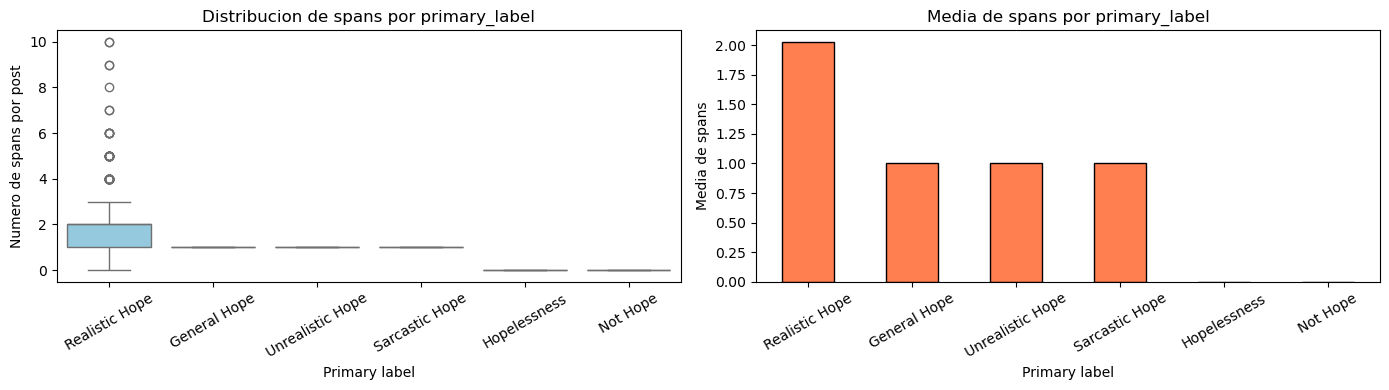

,posts,total_spans,mean_spans,median_spans,pct_with_spans
primary_label,,,,,
Realistic Hope,561,1137,2.026738,2.0,99.82
General Hope,749,749,1.000000,1.0,100.00
Unrealistic Hope,560,560,1.000000,1.0,100.00
Sarcastic Hope,560,560,1.000000,1.0,100.00
Hopelessness,335,0,0.000000,0.0,0.00
Not Hope,1120,0,0.000000,0.0,0.00


In [7]:
span_by_label = (
    train_df.groupby('primary_label')
    .agg(
        posts=('row_id', 'count'),
        total_spans=('span_count', 'sum'),
        mean_spans=('span_count', 'mean'),
        median_spans=('span_count', 'median'),
        pct_with_spans=('span_count', lambda values: (values > 0).mean()),
    )
    .sort_values('mean_spans', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(
    data=train_df,
    x='primary_label',
    y='span_count',
    order=span_by_label.index,
    ax=axes[0],
    color='skyblue',
)
axes[0].set_title('Distribucion de spans por primary_label')
axes[0].set_xlabel('Primary label')
axes[0].set_ylabel('Numero de spans por post')
axes[0].tick_params(axis='x', rotation=30)

span_by_label['mean_spans'].plot(
    kind='bar',
    ax=axes[1],
    color='coral',
    edgecolor='black',
)
axes[1].set_title('Media de spans por primary_label')
axes[1].set_xlabel('Primary label')
axes[1].set_ylabel('Media de spans')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_spans_by_primary_label.png'), dpi=150)
plt.show()

display(span_by_label.assign(pct_with_spans=lambda df: (100 * df['pct_with_spans']).round(2)))

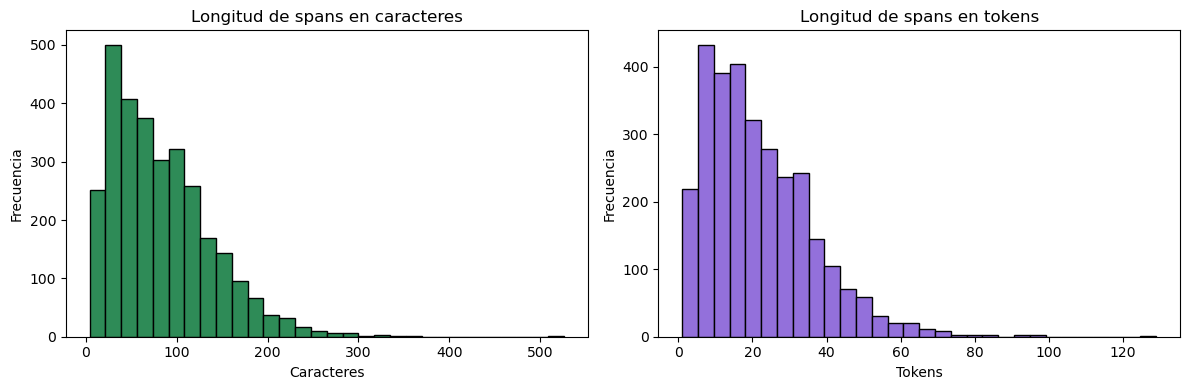

Spans anotados en train: 3006
Longitud media (chars): 83.0
Percentil 95 (chars): 183.0
Longitud media (tokens): 21.8
Percentil 95 (tokens): 49.0


In [8]:
span_lengths_chars = [
    len(span.get('span', ''))
    for record in train_records
    for span in (record.get('span_annotations') or [])
    if span.get('span')
]

tokenizer_preview = build_span_tokenizer(MODEL_NAME)
span_lengths_tokens = [
    len(tokenizer_preview.tokenize(span.get('span', '')))
    for record in train_records
    for span in (record.get('span_annotations') or [])
    if span.get('span')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(span_lengths_chars, bins=30, color='seagreen', edgecolor='black')
axes[0].set_title('Longitud de spans en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(span_lengths_tokens, bins=30, color='mediumpurple', edgecolor='black')
axes[1].set_title('Longitud de spans en tokens')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_span_lengths.png'), dpi=150)
plt.show()

print(f'Spans anotados en train: {len(span_lengths_chars)}')
print(f'Longitud media (chars): {np.mean(span_lengths_chars):.1f}')
print(f'Percentil 95 (chars): {np.percentile(span_lengths_chars, 95):.1f}')
print(f'Longitud media (tokens): {np.mean(span_lengths_tokens):.1f}')
print(f'Percentil 95 (tokens): {np.percentile(span_lengths_tokens, 95):.1f}')

## 4. Tokenizador y DataLoaders

In [9]:
tokenizer = build_span_tokenizer(MODEL_NAME)
print(f'Tokenizer cargado: {MODEL_NAME}')

sample_text_lengths = [
    len(tokenizer.encode(build_source_text(record), add_special_tokens=True))
    for record in train_records[:500]
]
print(f'Longitud media tokens (muestra 500): {np.mean(sample_text_lengths):.1f}')
print(f'Percentil 95: {np.percentile(sample_text_lengths, 95):.0f}')
print(f'Maximo: {max(sample_text_lengths)}')
print(f'MAX_LENGTH configurado: {MAX_LENGTH}')
print(f'STRIDE configurado: {STRIDE}')

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 333.1
Percentil 95: 769
Maximo: 5954
MAX_LENGTH configurado: 512
STRIDE configurado: 64


In [10]:
train_dataset, train_loader = build_dataloader(
    train_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=True, include_labels=True
)
dev_dataset, dev_loader = build_dataloader(
    dev_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=True
)
test_dataset, test_loader = build_dataloader(
    test_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=False
)

print(f'Features - Train: {len(train_dataset)} | Dev: {len(dev_dataset)} | Test: {len(test_dataset)}')
print(f'Batches - Train: {len(train_loader)} | Dev: {len(dev_loader)} | Test: {len(test_loader)}')

sample_batch = next(iter(train_loader))
print('\nForma de un batch:')
for key, value in sample_batch.items():
    print(f'  {key}: {tuple(value.shape)}')

Features - Train: 4692 | Dev: 1156 | Test: 2458
Batches - Train: 294 | Dev: 73 | Test: 154

Forma de un batch:
  input_ids: (16, 512)
  attention_mask: (16, 512)
  feature_id: (16,)
  labels: (16, 512)
  token_type_ids: (16, 512)


## 5. Comparación de Modelos

Antes de entrenar al maximo, comparamos varias arquitecturas con pocas epocas (`COMPARISON_EPOCHS`) para identificar la mas prometedora.
Solo el ganador se entrena despues con todas las epocas (`NUM_EPOCHS`).

In [11]:
CANDIDATE_MODELS = DEFAULT_CANDIDATE_MODELS

print('Candidatos de comparacion listos')
print(pd.DataFrame(CANDIDATE_MODELS)[['name', 'multilingual', 'description']])

Candidatos de comparacion listos
                           name  multilingual  \
0    microsoft/mdeberta-v3-base          True   
1              xlm-roberta-base          True   
2             xlm-roberta-large          True   
3  bert-base-multilingual-cased          True   

                                      description  
0      mDeBERTa v3 - strong multilingual baseline  
1  XLM-RoBERTa base - robust multilingual encoder  
2  XLM-RoBERTa large - higher capacity, more VRAM  
3     mBERT cased - classic multilingual baseline  


In [12]:
candidate_names = [m['name'] for m in CANDIDATE_MODELS if m['multilingual']]
comparison_results = compare_span_models(
    model_names=candidate_names,
    train_records=train_records,
    dev_records=dev_records,
    device=DEVICE,
    max_length=MAX_LENGTH,
    stride=STRIDE,
    batch_size=BATCH_SIZE,
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    grad_clip=GRAD_CLIP,
    save_dir=COMPARISON_DIR,
    monitor_metric='rouge1_f1',
    early_stopping_patience=2,
    use_class_weights=USE_CLASS_WEIGHTS,
)

ok_results = comparison_results[comparison_results['status'] == 'ok'].reset_index(drop=True)
if ok_results.empty:
    raise RuntimeError(
        'La comparacion no produjo modelos validos. Revisa conectividad y modelos de Hugging Face.'
    )

BEST_ARCH = ok_results.iloc[0]['model']
print(f'\nMejor arquitectura: {BEST_ARCH}')
print(f"   ROUGE-1 F1 (exploracion {COMPARISON_EPOCHS} epocas): {ok_results.iloc[0]['rouge1_f1']:.4f}")


  Evaluando: microsoft/mdeberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForTokenClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.dense.weight              | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                     

Iniciando entrenamiento: 3 epocas, lr=2e-05
- Total steps: 882 | Warmup steps: 88
- Early stopping: patience=2, monitor='rouge1_f1'



Train:   0%|          | 0/294 [00:00<?, ?it/s]

...

Train:   0%|          | 0/282 [00:00<?, ?it/s]

Eval Loss:   0%|          | 0/70 [00:00<?, ?it/s]

Epoca 3/3  [85.9s]
- Train Loss: 0.2570 | Dev Loss: 0.4126
- Dev rouge1_f1: 0.3857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Nuevo mejor modelo guardado (rouge1_f1=0.3857)

- Entrenamiento finalizado. Mejor rouge1_f1: 0.3857

  Ranking final de modelos
                       model  rouge1_f1  best_epoch  train_loss  dev_loss status
           xlm-roberta-large     0.5782           3      0.1760    0.3732     ok
  microsoft/mdeberta-v3-base     0.4790           3      0.2297    0.3126     ok
            xlm-roberta-base     0.4683           3      0.2318    0.3563     ok
bert-base-multilingual-cased     0.3857           3      0.2570    0.4126     ok

Resultados guardados en ./outputs/task_c_spans_notebook/model_comparison/model_comparison.csv

Mejor arquitectura: xlm-roberta-large
   ROUGE-1 F1 (exploracion 3 epocas): 0.5782


## 6. Entrenamiento Completo del Mejor Modelo

Entrenamos `BEST_ARCH` con `NUM_EPOCHS` epocas completas y early stopping.

In [13]:
tokenizer = build_span_tokenizer(BEST_ARCH)
train_dataset, train_loader = build_dataloader(
    train_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=True, include_labels=True
)
dev_dataset, dev_loader = build_dataloader(
    dev_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=True
)
test_dataset, test_loader = build_dataloader(
    test_records, tokenizer, max_length=MAX_LENGTH, stride=STRIDE,
    batch_size=BATCH_SIZE, shuffle=False, include_labels=False
)

class_weights = compute_class_weights(train_dataset) if USE_CLASS_WEIGHTS else torch.ones(NUM_LABELS)
model = build_span_model(BEST_ARCH).to(DEVICE).float()

n_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f'Arquitectura: {BEST_ARCH}')
print(f'Parametros entrenables: {n_params:,}')
print('Etiquetas BIO:', model.config.id2label)
print('Pesos de clase:', class_weights.tolist())
print(f'Loaders reconstruidos con tokenizer de: {BEST_ARCH}')

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Arquitectura: xlm-roberta-large
Parametros entrenables: 558,843,907
Etiquetas BIO: {0: 'O', 1: 'B-SPAN', 2: 'I-SPAN'}
Pesos de clase: [0.35061222314834595, 120.93289947509766, 7.164492607116699]
Loaders reconstruidos con tokenizer de: xlm-roberta-large


In [14]:
history, best_metric, best_epoch = train_span_model(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    train_loader=train_loader,
    dev_dataset=dev_dataset,
    dev_loader=dev_loader,
    dev_records=dev_records,
    device=DEVICE,
    class_weights=class_weights,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    grad_clip=GRAD_CLIP,
    save_dir=BEST_MODEL_DIR,
    early_stopping_patience=PATIENCE,
    monitor_metric='rouge1_f1',
    verbose=True,
)

save_json(history, os.path.join(OUTPUT_DIR, 'training_history.json'))

Iniciando entrenamiento: 25 epocas, lr=2e-05
- Total steps: 7000 | Warmup steps: 700
- Early stopping: patience=3, monitor='rouge1_f1'



Train:   0%|          | 0/280 [00:00<?, ?it/s]

Eval Loss:   0%|          | 0/70 [00:00<?, ?it/s]

Epoca 1/25  [288.5s]
- Train Loss: 0.7527 | Dev Loss: 0.3718
- Dev rouge1_f1: 0.3662


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Epoca 16/25  [138.8s]
- Train Loss: 0.0109 | Dev Loss: 2.1251
- Dev rouge1_f1: 0.7251
Sin mejora (1/3)



Train:   0%|          | 0/280 [00:00<?, ?it/s]

Eval Loss:   0%|          | 0/70 [00:00<?, ?it/s]

Eval Loss:   0%|          | 0/70 [00:00<?, ?it/s]

Epoca 18/25  [138.6s]
- Train Loss: 0.0087 | Dev Loss: 2.2509
- Dev rouge1_f1: 0.7304
Sin mejora (3/3)

- Early stopping activado en epoca 18
- Entrenamiento finalizado. Mejor rouge1_f1: 0.7367


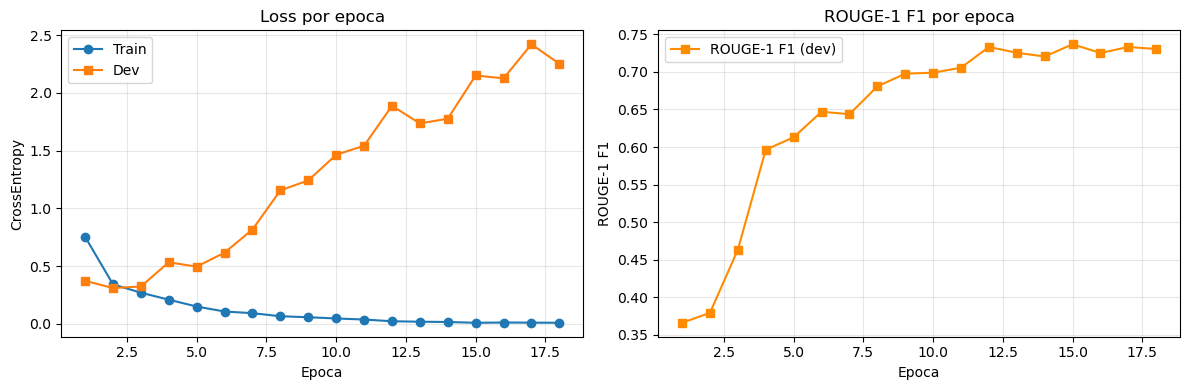

In [15]:
epochs_run = range(1, len(history['train_loss']) + 1)
dev_rouge = [metrics.get('rouge1_f1', 0.0) for metrics in history['dev_metrics']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_run, history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs_run, history['dev_loss'], marker='s', label='Dev')
axes[0].set_title('Loss por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('CrossEntropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_run, dev_rouge, marker='s', color='darkorange', label='ROUGE-1 F1 (dev)')
axes[1].set_title('ROUGE-1 F1 por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('ROUGE-1 F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'task_c_training_curves.png'), dpi=150)
plt.show()

## 7. Evaluación del Mejor Modelo en Dev

In [16]:
best_model = load_span_model(BEST_MODEL_DIR, device=DEVICE).float()
best_dev_loss, best_dev_metrics, best_dev_predictions = evaluate_span_model(
    best_model, dev_dataset, dev_loader, dev_records, DEVICE, class_weights
)

print(f'Dev loss: {best_dev_loss:.4f}')
print(format_metrics(best_dev_metrics))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Eval Loss:   0%|          | 0/70 [00:00<?, ?it/s]

Dev loss: 2.1502
rouge1_f1=0.7367


In [17]:
sample_rows = []
for record in dev_records[:10]:
    row_id = record.get('row_id')
    gold_spans = ' ||| '.join(span.get('span', '') for span in (record.get('span_annotations') or []))
    pred_spans = ' ||| '.join(candidate.text for candidate in best_dev_predictions.get(row_id, []))
    sample_rows.append({
        'row_id': row_id,
        'primary_label': record.get('primary_label'),
        'gold_spans': gold_spans,
        'pred_spans': pred_spans,
        'source_text': build_source_text(record)[:220],
    })

display(pd.DataFrame(sample_rows))

,row_id,primary_label,gold_spans,pred_spans,source_text
0,7555,General Hope,sigo esperando que algún día comprendan que es...,sigo esperando que algún día comprendan que es...,Mi hermano no entiende por qué estudio tanto\n...
1,1522,Unrealistic Hope,"once I lose 200 pounds, become a millionaire, ...","once I lose 200 pounds, become a millionaire, ...",My Ex Will Definitely Come Back Once They See ...
2,4278,Unrealistic Hope,"once we move into this home, all my stress and...",I truly believe that once we move into this ho...,Housing Dream Update: Found Perfect Home and F...
3,7155,Not Hope,,,Está mal pensar que es de mal gusto exigir reg...
4,6539,Unrealistic Hope,"si mi jefe realmente me amara como persona, ve...","si mi jefe realmente me amara como persona, ve...",¿Cómo puedo conseguir que mi jefe me ame tanto...
5,8916,Hopelessness,,i wont be dead before i read replies,i wanna die\nim 15 and basically everyone in m...
6,7256,Sarcastic Hope,claro que esta vez será diferente,claro que esta vez será diferente,"Claro, seguro que esta vez será diferente\nAhí..."
7,8754,Not Hope,,,¿Se entiende mi fragmento?\nContexto: Mis pers...
8,7070,Unrealistic Hope,I hope we pull off the impossible and win it a...,I'm convinced that if we just believe hard eno...,My team's washed-up roster will somehow win th...
9,4040,Realistic Hope,me gustaría que leyeran los primeros capítulos...,me gustaría ||| que leyeran los primeros capít...,"Quiero saber su opinión\nHola, espero estén bi..."


## 8. Optimización del Postproceso

In [18]:
print('Postproceso: se usa tune_postprocess desde src/span_experiments.py')

Postproceso: se usa tune_postprocess desde src/span_experiments.py


In [19]:
dev_logits = collect_logits(best_model, dev_loader, DEVICE)

tuning_results, OPTIMAL_POSTPROCESS, baseline_metrics, best_dev_metrics_tuned, best_dev_predictions_tuned = tune_postprocess(
    dataset=dev_dataset,
    logits_by_feature_id=dev_logits,
    records=dev_records,
    max_spans_grid=[2, 3, 4],
    overlap_threshold_grid=[0.5, 0.6, 0.7],
    min_span_score_grid=[0.00, 0.35, 0.45, 0.55],
)

tuning_results.to_csv(os.path.join(OUTPUT_DIR, 'postprocess_tuning_results.csv'), index=False)

print('Baseline (postproceso por defecto):')
print(format_metrics(baseline_metrics))
print('\nMejor configuracion de postproceso:')
print(OPTIMAL_POSTPROCESS)
print('\nMetricas finales en dev (tuned):')
print(format_metrics(best_dev_metrics_tuned))
display(tuning_results.head(10))

Baseline (postproceso por defecto):
rouge1_f1=0.7367

Mejor configuracion de postproceso:
{'max_spans': 4, 'overlap_threshold': 0.7, 'min_span_score': 0.55}

Metricas finales en dev (tuned):
rouge1_f1=0.7385


,max_spans,overlap_threshold,min_span_score,rouge1_f1
0,4,0.7,0.55,0.738530
1,4,0.5,0.55,0.738530
2,4,0.6,0.55,0.738530
3,3,0.6,0.55,0.737686
4,3,0.7,0.55,0.737686
5,3,0.5,0.55,0.737686
6,4,0.7,0.00,0.737550
7,4,0.5,0.45,0.737550
8,4,0.5,0.35,0.737550
9,4,0.5,0.00,0.737550


## 9. Análisis de Errores

In [20]:
errors = []
for record in dev_records:
    row_id = record.get('row_id')
    gold_spans = [span.get('span', '').strip() for span in (record.get('span_annotations') or []) if span.get('span')]
    pred_spans = [candidate.text.strip() for candidate in best_dev_predictions_tuned.get(row_id, []) if candidate.text.strip()]
    if gold_spans != pred_spans:
        errors.append({
            'row_id': row_id,
            'primary_label': record.get('primary_label'),
            'gold': gold_spans,
            'pred': pred_spans,
            'text': build_source_text(record),
        })

error_rate = len(errors) / len(dev_records) * 100
print(f'Muestras con al menos 1 error: {len(errors)} ({error_rate:.1f}%)')
print()

for e in errors[:5]:
    print(f"row_id={e['row_id']} | primary_label={e['primary_label']}")
    print(f"  Gold: {e['gold']}")
    print(f"  Pred: {e['pred']}")
    print(f"  Texto: {e['text'][:180]}...")
    print()

Muestras con al menos 1 error: 498 (51.2%)

row_id=7555 | primary_label=General Hope
  Gold: ['sigo esperando que algún día comprendan que esto es lo que realmente quiero hacer']
  Pred: ['sigo esperando que algún día comprendan que esto es lo que realmente quiero hacer y']
  Texto: Mi hermano no entiende por qué estudio tanto
Estoy harto de que mi familia me cuestione constantemente sobre mis decisiones. Mi hermano mayor siempre me dice que soy un soñador y q...

row_id=4278 | primary_label=Unrealistic Hope
  Gold: ['once we move into this home, all my stress and anger issues will just disappear']
  Pred: ['I truly believe that once we move into this home, all my stress and anger issues will just disappear', "I'", "owning this house together will completely transform me into the calm, patient person I've always wanted to be"]
  Texto: Housing Dream Update: Found Perfect Home and Finally Fixed Everything
I'm so excited to share that my boyfriend and I just put an offer on our dream hou

## 10. Generación de Predicciones para Test (Submission)

In [21]:
test_logits = collect_logits(best_model, test_loader, DEVICE)
test_predictions_tuned = aggregate_predictions_tuned(
    test_dataset,
    test_logits,
    max_spans=OPTIMAL_POSTPROCESS['max_spans'],
    overlap_threshold=OPTIMAL_POSTPROCESS['overlap_threshold'],
    min_span_score=OPTIMAL_POSTPROCESS['min_span_score'],
)

primary_label_mapping = load_primary_labels(PRIMARY_LABELS_PATH) if PRIMARY_LABELS_PATH else None
submission_records = predictions_to_submission(
    test_records,
    test_predictions_tuned,
    primary_label_mapping=primary_label_mapping,
)

submission_path = os.path.join(OUTPUT_DIR, SUBMISSION_NAME)
save_json(submission_records, submission_path)
print(f'Submission guardada en: {submission_path}')
display(pd.DataFrame(submission_records).head(10))

Submission guardada en: ./outputs/task_c_spans_notebook/submission_task_c_notebook.json


,row_id,span_annotations
0,17,"[{'span': 'Sí, claro, seguro que todo va a est..."
1,3512,[]
2,4863,[{'span': 'Quiero realizar trabajo social y/o ...
3,6917,"[{'span': 'juntos'}, {'span': 'si realmente po..."
4,8586,[{'span': 'I'm sure things will magically get ...
5,4432,[{'span': 'si logro identificar la raíz del pr...
6,3328,[{'span': 'Perhaps the next election will fina...
7,597,[{'span': 'they’ll break up'}]
8,8312,[]
9,4707,[]


## 11. Guardado del Experimento

In [22]:
experiment_config = {
    'model_name': BEST_ARCH,
    'comparison_epochs': COMPARISON_EPOCHS,
    'max_length': MAX_LENGTH,
    'stride': STRIDE,
    'batch_size': BATCH_SIZE,
    'epochs': NUM_EPOCHS,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'warmup_ratio': WARMUP_RATIO,
    'patience': PATIENCE,
    'grad_clip': GRAD_CLIP,
    'use_class_weights': USE_CLASS_WEIGHTS,
    'seed': SEED,
    'best_dev_loss': best_dev_loss,
    'best_dev_metrics_default_postprocess': best_dev_metrics,
    'best_dev_metrics_tuned_postprocess': best_dev_metrics_tuned,
    'optimal_postprocess': OPTIMAL_POSTPROCESS,
    'train_examples': len(train_records),
    'dev_examples': len(dev_records),
    'test_examples': len(test_records),
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
save_json(experiment_config, config_path)
print(f'Configuracion guardada en: {config_path}')
print(json.dumps(experiment_config, indent=2, ensure_ascii=False))

Configuracion guardada en: ./outputs/task_c_spans_notebook/experiment_config.json
{
  "model_name": "xlm-roberta-large",
  "comparison_epochs": 3,
  "max_length": 512,
  "stride": 64,
  "batch_size": 16,
  "epochs": 25,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "patience": 3,
  "grad_clip": 1.0,
  "use_class_weights": true,
  "seed": 42,
  "best_dev_loss": 2.150165031637464,
  "best_dev_metrics_default_postprocess": {
    "rouge1_f1": 0.7367060691317274
  },
  "best_dev_metrics_tuned_postprocess": {
    "rouge1_f1": 0.7385299233922895
  },
  "optimal_postprocess": {
    "max_spans": 4,
    "overlap_threshold": 0.7,
    "min_span_score": 0.55
  },
  "train_examples": 3885,
  "dev_examples": 972,
  "test_examples": 2082
}
